In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
df = pd.read_csv('../data/Telco_customer_churn.csv')
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

In [42]:
features = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges'
]

X = df[features].copy()
print(X)

      Tenure Months  Monthly Charges Total Charges
0                 2            53.85        108.15
1                 2            70.70        151.65
2                 8            99.65         820.5
3                28           104.80       3046.05
4                49           103.70        5036.3
...             ...              ...           ...
7038             72            21.15        1419.4
7039             24            84.80        1990.5
7040             72           103.20        7362.9
7041             11            29.60        346.45
7042             66           105.65        6844.5

[7043 rows x 3 columns]


In [43]:
for column in features:
    X[column] = pd.to_numeric(X[column], errors='coerce')

print("Before Handling Null Values Shape : ", X.shape)

X = X.dropna()
print("After Handling Null Values Shape : ", X.shape)

Before Handling Null Values Shape :  (7043, 3)
After Handling Null Values Shape :  (7032, 3)


In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [45]:
inertia_values = []
k_values = range(1,11)

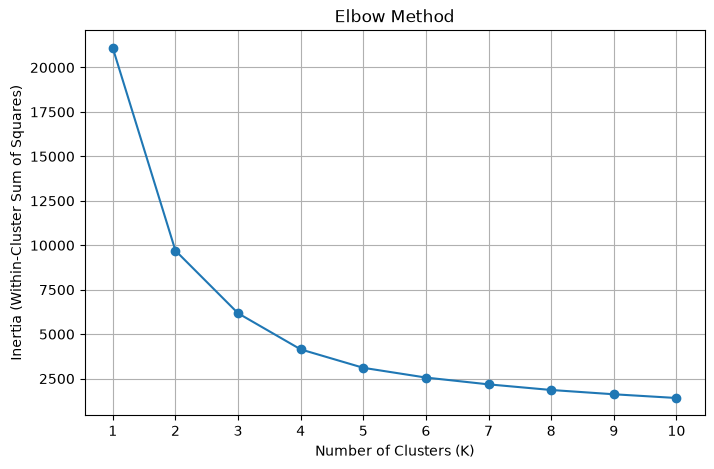

In [46]:
for k in k_values:
    kMeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kMeans.fit(X_scaled)
    inertia_values.append(kMeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_values), inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method")
plt.xticks(list(k_values))
plt.grid(True)
plt.show()

In [ ]:
shlhoutte_scores = {}

for k in range(2,11):
    kMeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kMeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    shlhoutte_scores[k] = score

for k, score in shlhoutte_scores.items():
    print(f"K : {k} : {score : .4f}")

K : 2 :  0.4795
K : 3 :  0.4513
K : 4 :  0.4721
K : 5 :  0.4437
K : 6 :  0.4393
K : 7 :  0.4325
K : 8 :  0.4275
K : 9 :  0.4321
K : 10 :  0.4347


In [51]:
best_shlhoutte_scores_k = max(
    shlhoutte_scores,
    key=shlhoutte_scores.get
)

print("\nK with Highest Silhouette Score:", best_shlhoutte_scores_k)


K with Highest Silhouette Score: 2


In [52]:
k = best_shlhoutte_scores_k
kMeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters_labels = kMeans.fit_predict(X_scaled)
clustered_data = df.loc[X.index].copy()
clustered_data["Cluster"] = clusters_labels

print("\nClustered Data:")
print(clustered_data.head(10))


Clustered Data:
   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   
5  4190-MFLUW      1  United States  California  Los Angeles     90020   
6  8779-QRDMV      1  United States  California  Los Angeles     90022   
7  1066-JKSGK      1  United States  California  Los Angeles     90024   
8  6467-CHFZW      1  United States  California  Los Angeles     90028   
9  8665-UTDHZ      1  United States  California  Los Angeles     90029   

                 Lat Long   Latitude   Longitude  Gender  ...  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...   
1   34.059281, -118.30742  34.059281 -

In [55]:
print("\nNumber of Customers in Each Cluster:")
print(clustered_data["Cluster"].value_counts().sort_index())

if "Churn Label" in clustered_data.columns:
    print("\nChurn Distribution by Cluster:")
    print(
        pd.crosstab(
            clustered_data["Cluster"],
            clustered_data["Churn Label"],
            normalize="index"
        ).round(3)
    )

print("\n================ FINAL SUMMARY ================")
print("Number of clusters:", k)
print("Inertia:", round(kMeans.inertia_, 2))
print("Silhouette Score:", round(
    silhouette_score(X_scaled, clusters_labels), 4
))
print("\nCluster Sizes:")
print(clustered_data["Cluster"].value_counts().sort_index())


Number of Customers in Each Cluster:
Cluster
0    2360
1    4672
Name: count, dtype: int64

Churn Distribution by Cluster:
Churn Label     No    Yes
Cluster                  
0            0.831  0.169
1            0.685  0.315

================ FINAL SUMMARY ================
Number of clusters: 2
Inertia: 9700.83
Silhouette Score: 0.4795

Cluster Sizes:
Cluster
0    2360
1    4672
Name: count, dtype: int64
